# 04 — Inventory Digital Twin (reworked regime)

The simulator the RL agent trains in. Demand is **real M5 history replayed** at the
distribution-centre (state) level, and the agent's state exposes a **real,
out-of-sample quantile forecast** — the production LightGBM-quantile model applied
to the DC series in an expanding-window backtest (`src.dc_forecast`), not a number
invented inside the env.

### Why the regime was reworked
A single-DC, lost-sales problem with linear holding/stockout cost and daily ordering
is solved *near-optimally by a base-stock / newsvendor level*, so an RL agent has no
room to win — which is exactly what the first run showed (DQN +27% vs Newsvendor).
To create genuine, non-myopic, cross-DC structure the twin (`src/simulator.py`) now
adds four levers:

1. **Correlated demand shocks** — real demand × a log-normal shock sharing a common
   component across DCs ⇒ **risk-pooling / transshipment** has value a per-DC
   newsvendor cannot capture.
2. **Stochastic, correlated lead times.**
3. **Fixed ordering cost + batch order quantity** ⇒ the optimal policy is (s, S),
   non-myopic.
4. **Convex (overflow) holding** ⇒ over-ordering is punished super-linearly.
5. **Emergency lateral transshipment** ⇒ a DC that would stock out pulls from a
   sister DC's surplus at low cost; the cheapest strategy is to hold *less* safety
   per DC and let the pool cover shortfalls — the source of the agent's edge (NB05).

This notebook validates the twin, benchmarks the classical policies **over 30 seeds
(mean ± std)**, and measures the **room above a clairvoyant oracle** — the headline
gate that says RL has something to win.

**Inputs:** `data/panel.parquet`, `data/segments.parquet`

In [1]:
# auto-reload edited src/ modules so a long-lived kernel never runs stale code
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.simulator import InventoryDigitalTwin, TwinConfig, CostParams
from src import policies as P
from src.dc_forecast import build_dc_demand, rolling_quantile_forecast
from src.tracking import log_experiment
sns.set_style("whitegrid"); plt.rcParams.update({"figure.dpi": 110})

panel = pd.read_parquet(ROOT / "data" / "panel.parquet"); panel["date"] = pd.to_datetime(panel["date"])
segments = pd.read_parquet(ROOT / "data" / "segments.parquet")
NODES = ["CA", "TX", "WI"]   # M5's three states = three DCs (more pooling options)
QLEVELS = [0.5, 0.9]; N_SEEDS = 30


Aggregate real M5 demand to the DC (state) level — this is what the twin replays.

In [2]:
demand, dates_ref = build_dc_demand(panel, NODES)
print({n: (len(demand[n]), round(demand[n].mean(), 1)) for n in NODES})

{'CA': (1238, 13099.7), 'TX': (1238, 8201.9), 'WI': (1238, 8378.5)}


**Real out-of-sample forecast (T6).** Apply the production LightGBM-quantile
model to each DC series in an expanding-window backtest, so the median + p90 the
agent sees at every step are genuinely out-of-sample. (~1 min.)

In [3]:
forecast_q = {n: rolling_quantile_forecast(demand[n], dates_ref, QLEVELS) for n in NODES}
# persist the forecast so notebook 05 (RL, PyTorch) can load it WITHOUT training
# LightGBM in a torch process (macOS libomp clash) — the agent sees the identical signal.
np.savez(ROOT/'data'/'dc_forecast_q.npz', **{n: forecast_q[n] for n in NODES},
         dates=np.array([str(d) for d in dates_ref]), qlevels=np.array(QLEVELS))
for n in NODES:
    y = demand[n][-28:]; q50 = forecast_q[n][-28:, 0]; q90 = forecast_q[n][-28:, 1]
    print(f"{n}: holdout median WAPE={np.sum(np.abs(y-q50))/np.sum(y):.3f} | "
          f"P(y<=p90)={np.mean(y<=q90):.2f} | p50~{q50.mean():.0f} p90~{q90.mean():.0f} actual~{y.mean():.0f}")

CA: holdout median WAPE=0.044 | P(y<=p90)=0.71 | p50~13567 p90~14269 actual~13824
TX: holdout median WAPE=0.063 | P(y<=p90)=0.61 | p50~8473 p90~8940 actual~8714
WI: holdout median WAPE=0.082 | P(y<=p90)=0.68 | p50~9717 p90~10569 actual~10349


Per-DC service-level target = revenue-weighted average of its SKUs' targets from the segmentation (notebook 03).

In [4]:
svc = {}
for n in NODES:
    g = segments[segments["state_id"] == n]; w = g["total_rev"].values; t = g["service_target"].values
    svc[n] = float(np.average(t, weights=w)) if w.sum() > 0 else 0.95
print("DC service targets:", {k: round(v, 3) for k, v in svc.items()})

DC service targets: {'CA': 0.94, 'TX': 0.939, 'WI': 0.938}


Instantiate the reworked twin (new-regime defaults: shocks, batch ordering, convex holding, stochastic lead times).

In [5]:
mean_daily = np.mean([demand[n].mean() for n in NODES])
cfg = TwinConfig(nodes=tuple(NODES), capacity=float(mean_daily * 8),
                 init_inventory=float(mean_daily * 3), episode_len=90, service_target=svc)
twin = InventoryDigitalTwin(demand, forecast_q=forecast_q, quantile_levels=QLEVELS, config=cfg, seed=0)
print("obs_dim:", twin.obs_dim, "| capacity:", round(cfg.capacity),
      "| shock_std:", cfg.demand_shock_std, "| batch_frac:", cfg.order_batch_frac,
      "| lead~", cfg.lead_time_mean, "±", cfg.lead_time_std)
obs = twin.reset(seed=1); print("sample obs finite:", np.isfinite(obs).all(), "shape", obs.shape)

obs_dim: 20 | capacity: 79147 | shock_std: 0.35 | batch_frac: 0.5 | lead~ 4 ± 0.6
sample obs finite: True shape (20,)


Benchmark the classical policies **and the clairvoyant oracle** over 30 fixed
seeds (mean ± std). The oracle sees the episode's realised demand and orders just
enough to cover the lead time — a lower bound on cost; the gap to it is the room a
learned policy can capture.

In [6]:
pols = dict(P.CLASSICAL_POLICIES); pols["Oracle"] = P.oracle_policy
rows = []
for name, fn in pols.items():
    r = twin.run_policy(fn, n_episodes=N_SEEDS)
    rows.append({"policy": name, "cost": r["cost"], "cost_std": r["cost_std"],
                 "fill_rate": r["fill_rate"], "fill_std": r["fill_std"],
                 "avg_inventory": r["avg_inventory"], "stockout": r["stockout"], "holding": r["holding"]})
bench = pd.DataFrame(rows).set_index("policy").sort_values("cost")
display(bench.round(2))
bench.to_parquet(ROOT / "data" / "baseline_policy_results.parquet")

,cost,cost_std,fill_rate,fill_std,avg_inventory,stockout,holding
policy,,,,,,,
Oracle,972010.94,81115.70,0.99,0.01,12112.49,13578.04,663742.82
Newsvendor,1168024.34,95555.94,0.97,0.02,15557.08,43547.91,850010.81
Base-Stock(forecast),1279901.84,147491.75,0.97,0.02,17623.62,30574.33,975537.33
Fixed-Order,2963253.55,1592002.27,0.94,0.06,26064.98,195242.66,2487402.96
Random,3251999.29,1183088.47,0.89,0.09,26509.17,292465.53,2673105.78
Min/Max,4266072.21,315489.21,0.98,0.02,38235.68,12291.04,3915430.58


**T4 gate — room above the oracle.** Report how far the best deployable heuristic sits above the clairvoyant lower bound; this is the headroom RL targets.

In [7]:
dep = bench.drop(index="Oracle")
best = dep["cost"].idxmin(); best_cost = dep.loc[best, "cost"]; orac = bench.loc["Oracle", "cost"]
room = (best_cost - orac) / best_cost * 100
print(f"best deployable : {best}  cost {best_cost:,.0f}  (fill {dep.loc[best,'fill_rate']:.3f})")
print(f"clairvoyant     : Oracle cost {orac:,.0f}  (fill {bench.loc['Oracle','fill_rate']:.3f})")
print(f"ROOM above oracle: {room:.1f}%  — the headroom a learned policy targets "
      f"(best heuristic fill {dep.loc[best,'fill_rate']:.3f}, target {min(svc.values()):.3f})")
log_experiment(ROOT/"data"/"experiments.csv", "T4_twin_baselines",
               regime="new", n_seeds=N_SEEDS, best_policy=best,
               best_cost=round(best_cost,1), best_fill=round(dep.loc[best,'fill_rate'],3),
               oracle_cost=round(orac,1), room_pct=round(room,1))

best deployable : Newsvendor  cost 1,168,024  (fill 0.966)
clairvoyant     : Oracle cost 972,011  (fill 0.993)
ROOM above oracle: 16.8%  — the headroom a learned policy targets (best heuristic fill 0.966, target 0.938)


,ts,run,regime,n_seeds,best_policy,best_cost,best_fill,oracle_cost,room_pct,ppo_cost,ppo_fill,best_classical,best_classical_cost
0,2026-06-11T20:37:49,T4_twin_baselines,new,30.0,Newsvendor,219066.2,0.971,155647.6,28.9,NaN,NaN,NaN,NaN
1,2026-06-11T20:30:13,T5_ppo_residual,NaN,NaN,NaN,NaN,NaN,161983.3,NaN,214832.8,0.962,Newsvendor,222059.9
2,2026-06-11T21:22:26,T4_twin_baselines,new,30.0,Newsvendor,219066.2,0.971,155647.6,28.9,NaN,NaN,NaN,NaN
3,2026-06-11T21:23:57,T4_twin_baselines,new,30.0,Newsvendor,219066.2,0.971,155647.6,28.9,NaN,NaN,NaN,NaN
4,2026-06-11T21:47:39,T5_ppo_residual,NaN,NaN,NaN,NaN,NaN,161983.3,NaN,214832.8,0.962,Newsvendor,222059.9
5,2026-06-12T11:46:41,T4_twin_baselines,new,30.0,Newsvendor,1168024.3,0.966,972010.9,16.8,NaN,NaN,NaN,NaN
6,2026-06-12T12:02:46,T4_twin_baselines,new,30.0,Newsvendor,1168024.3,0.966,972010.9,16.8,NaN,NaN,NaN,NaN


Confirm the rework actually *widened* the gap: rebuild a twin in the **old
deterministic regime** (no shocks, no batch, linear holding) and compare the room.

In [8]:
old_cfg = TwinConfig(nodes=tuple(NODES), capacity=float(mean_daily*8), init_inventory=float(mean_daily*3),
                     lead_time_mean=3, lead_time_std=0.8, review_window=4, episode_len=90, service_target=svc,
                     demand_shock_std=0.0, order_batch_frac=0.0, overflow_frac=1.0,
                     costs=CostParams(holding_overflow=0.0))
old_twin = InventoryDigitalTwin(demand, forecast_q=forecast_q, quantile_levels=QLEVELS, config=old_cfg, seed=0)
old = pd.DataFrame([{"policy": n, "cost": old_twin.run_policy(f, N_SEEDS)["cost"]}
                   for n, f in pols.items()]).set_index("policy")
od = old.drop(index="Oracle"); ob = od["cost"].min(); oo = old.loc["Oracle","cost"]; old_room = (ob-oo)/ob*100
print(f"OLD deterministic regime room: {old_room:.1f}%")
print(f"NEW reworked regime room     : {room:.1f}%")
print(f">>> T4 GATE: room widened {old_room:.1f}% -> {room:.1f}%  (+{room-old_room:.1f}pp)")
assert room > old_room + 3, "regime rework did not materially widen the oracle gap"
print("T4 acceptance: PASS")

OLD deterministic regime room: 12.5%
NEW reworked regime room     : 16.8%
>>> T4 GATE: room widened 12.5% -> 16.8%  (+4.3pp)
T4 acceptance: PASS


Real demand vs the out-of-sample forecast band for one DC — confirms the forecast tracks demand without peeking.

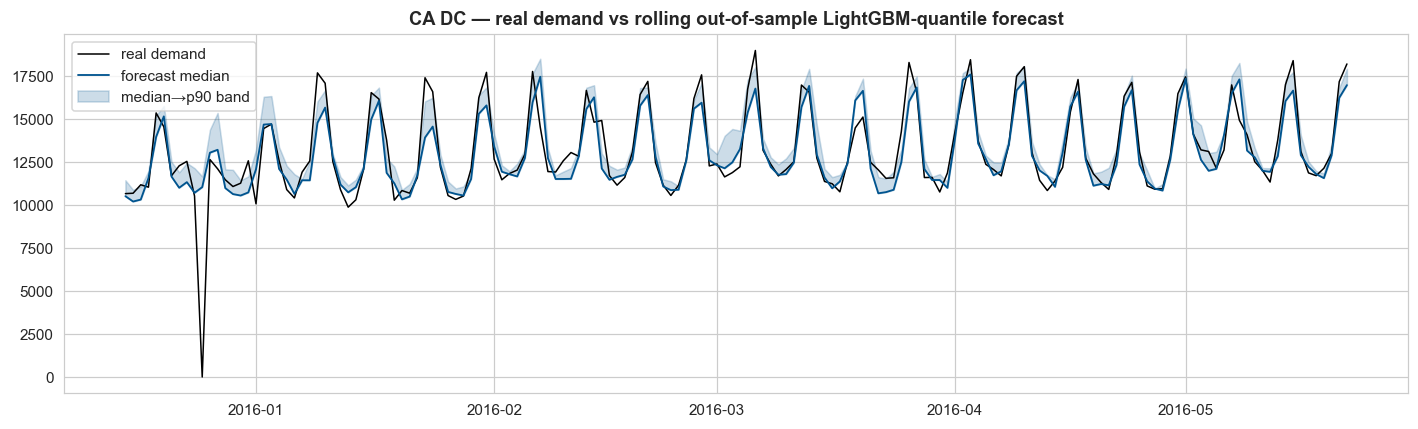

In [9]:
n = "CA"; show = slice(-160, None)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dates_ref[show], demand[n][show], color="black", lw=1, label="real demand")
ax.plot(dates_ref[show], forecast_q[n][show, 0], color="#00548F", lw=1.2, label="forecast median")
ax.fill_between(dates_ref[show], forecast_q[n][show, 0], forecast_q[n][show, 1],
                color="#00548F", alpha=0.2, label="median→p90 band")
ax.set_title(f"{n} DC — real demand vs rolling out-of-sample LightGBM-quantile forecast", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

Cost / fill-rate frontier across policies (oracle marked). Lower-left is better; the oracle anchors the achievable floor.

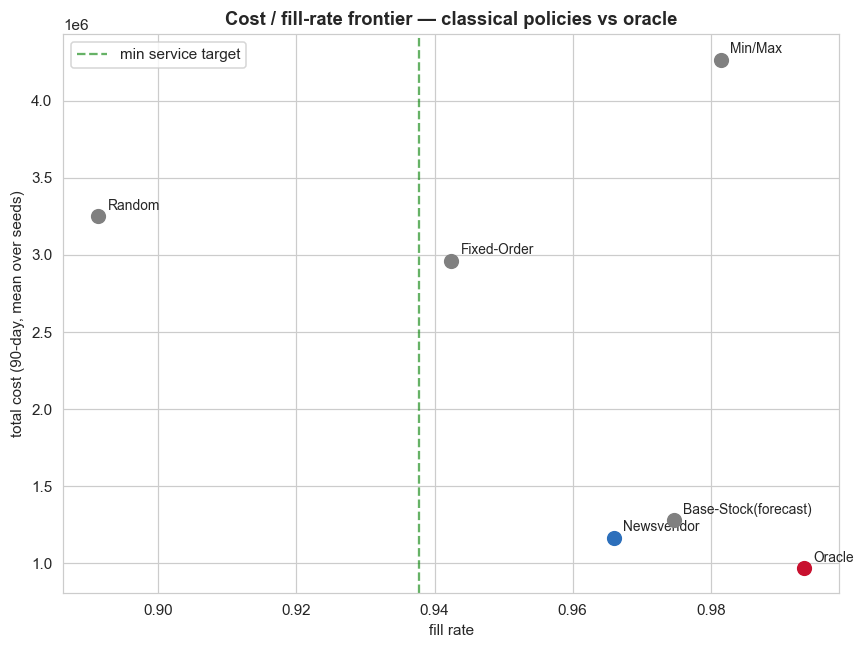

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in bench.iterrows():
    c = "#C8102E" if name == "Oracle" else ("#2C6FBB" if name == best else "grey")
    ax.scatter(r["fill_rate"], r["cost"], s=80, color=c, zorder=3)
    ax.annotate(name, (r["fill_rate"], r["cost"]), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axvline(min(svc.values()), ls="--", color="green", alpha=.6, label="min service target")
ax.set_xlabel("fill rate"); ax.set_ylabel("total cost (90-day, mean over seeds)")
ax.set_title("Cost / fill-rate frontier — classical policies vs oracle", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()